<a href="https://colab.research.google.com/github/ShashikanthKungulwar/DL/blob/main/MNIST_FASHION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:


train_data = datasets.FashionMNIST(root="data",train=True,download=True,transform = transforms.ToTensor())
test_data = datasets.FashionMNIST(root = "data",train=False,download=True,transform = transforms.ToTensor())


In [ ]:
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=batch_size,shuffle=False)


for batch,(x,y) in enumerate(train_dataloader):
    print("x shape is [batch_size,channels,height,width]",x.shape)
    print("y shape is",y.shape)
    break

x shape is [batch_size,channels,height,width] torch.Size([64, 1, 28, 28])
y shape is torch.Size([64])


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class Model(nn.Module):
  def __init__(self):
    super(Model,self).__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,512),
        nn.ReLU(),
        nn.Linear(512,10)
    )
  def forward(self,x):
    x=self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model = Model().to(device)

In [ ]:
epoches =  5
learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

In [ ]:
def train(data_loader,model,loss_fn,optimizer):
  model.train()
  size = len(data_loader.dataset)
  for batch,(x,y) in enumerate(data_loader):
    x,y = x.to(device),y.to(device)


    y_pred = model(x)
    loss = loss_fn(y_pred,y)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if(batch%100 == 0):
      current = (batch+1)*len(x)
      print(f"{loss.item()} {current}/{size}")


In [ ]:
def test(data_loader,model,loss_fn):
  model.eval()
  total_loss = 0
  correct =0;
  with torch.no_grad():
    for batch,(x,y) in enumerate(data_loader):
      x,y = x.to(device),y.to(device)
      y_pred = model(x)
      loss = loss_fn(y_pred,y)
      total_loss += loss.item()
      correct += torch.sum(torch.argmax(y_pred,axis = -1)==y).item()
    num_batches = len(data_loader)
    size = len(data_loader.dataset)
    print("loss: ",total_loss/num_batches)
    print("accuracy: ",correct/size)

In [ ]:
for epoch in range(epoches):
  train(train_dataloader,model,loss_fn,optimizer)
  test(test_dataloader,model,loss_fn)

2.2997684478759766 64/60000
2.283550262451172 6464/60000
2.278343677520752 12864/60000
2.2645485401153564 19264/60000
2.2551159858703613 25664/60000
2.2434346675872803 32064/60000
2.2337803840637207 38464/60000
2.217106580734253 44864/60000
2.2016611099243164 51264/60000
2.180128574371338 57664/60000
loss:  2.180540765167042
accuracy:  0.3294
2.187985420227051 64/60000
2.185353994369507 6464/60000
2.1461877822875977 12864/60000
2.1018028259277344 19264/60000
2.092371940612793 25664/60000
2.064958333969116 32064/60000
1.9898931980133057 38464/60000
2.01387619972229 44864/60000
1.9505908489227295 51264/60000
1.8914306163787842 57664/60000
loss:  1.9077556755892031
accuracy:  0.443
1.8639068603515625 64/60000
1.9282374382019043 6464/60000
1.8013222217559814 12864/60000
1.750477910041809 19264/60000
1.7431046962738037 25664/60000
1.6916722059249878 32064/60000
1.7749978303909302 38464/60000
1.5809273719787598 44864/60000
1.5475268363952637 51264/60000
1.5809898376464844 57664/60000
loss:  

In [ ]:
for epoch in range(epoches-2):
  train(train_dataloader,model,loss_fn,optimizer)
  test(test_dataloader,model,loss_fn)

1.042479157447815 64/60000
1.0729336738586426 6464/60000
1.0083508491516113 12864/60000
1.1400920152664185 19264/60000
0.9112535715103149 25664/60000
1.1231129169464111 32064/60000
1.0527942180633545 38464/60000
1.069225788116455 44864/60000
1.0413897037506104 51264/60000
0.893429160118103 57664/60000
loss:  0.9736236246528139
accuracy:  0.652
0.9261464476585388 64/60000
0.8819202184677124 6464/60000
0.9348852038383484 12864/60000
1.0255508422851562 19264/60000
0.8474147915840149 25664/60000
0.886186957359314 32064/60000
0.9381759166717529 38464/60000
1.1293517351150513 44864/60000
0.914566159248352 51264/60000
0.8882519602775574 57664/60000
loss:  0.8997610325266601
accuracy:  0.6712
0.9944629073143005 64/60000
0.9942531585693359 6464/60000
0.9646737575531006 12864/60000
0.8036305904388428 19264/60000
0.7615295052528381 25664/60000
0.8870217800140381 32064/60000
0.7711585760116577 38464/60000
0.9710559248924255 44864/60000
0.715964674949646 51264/60000
0.7724727392196655 57664/60000
l

In [ ]:
for epoch in range(epoches-3):
  train(train_dataloader,model,loss_fn,optimizer)
  test(test_dataloader,model,loss_fn)

0.7488007545471191 64/60000
0.7943780422210693 6464/60000
0.8087815046310425 12864/60000
0.9384320974349976 19264/60000
0.7509924173355103 25664/60000
0.9423254728317261 32064/60000
0.8821091651916504 38464/60000
0.7933769822120667 44864/60000
0.6494871377944946 51264/60000
0.8245899677276611 57664/60000
loss:  0.8068499800505912
accuracy:  0.6983
0.8029302358627319 64/60000
0.7970763444900513 6464/60000
0.6666910648345947 12864/60000
0.6948996186256409 19264/60000
0.7524347305297852 25664/60000
0.7685292363166809 32064/60000
0.6075246334075928 38464/60000
0.7279866337776184 44864/60000
0.7190485596656799 51264/60000
0.7738944292068481 57664/60000
loss:  0.7737927801290135
accuracy:  0.7203


In [ ]:
#here if we cause any intereuppt  then run for once again like follows and then it will be okay for 1 epoch

train(train_dataloader,model,loss_fn,optimizer)


0.6859303712844849 64/60000
0.7091164588928223 6464/60000
0.5843627452850342 12864/60000
0.728576123714447 19264/60000
0.7382388710975647 25664/60000
0.5231548547744751 32064/60000
0.8377012014389038 38464/60000
0.717461109161377 44864/60000
0.8705832362174988 51264/60000
0.7930790185928345 57664/60000


In [ ]:
#now to save the model

torch.save(model.state_dict(),"model.pth")

In [ ]:
model1 = Model()
model1 = model1.to(device)
model1.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [ ]:
test(test_dataloader,model1,loss_fn)

loss:  0.7472284910785165
accuracy:  0.7275


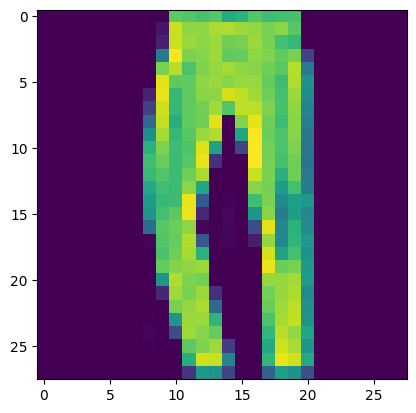

Trouser


In [ ]:
outputs = [
"T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"]


(x,y) = test_data[5]
with torch.no_grad():
  x = x.to(device)
  y_pred = model(x)
  plt.imshow(x.cpu().squeeze())
  plt.show()
  print(outputs[torch.argmax(y_pred,axis = 1)])
